# 9.5 LLaMA Architecture - Complete Guide

> **LLaMA (Large Language Model Meta AI)** is Meta's family of open-weight large language models. It introduced several architectural innovations over the original GPT/Transformer decoder that have become the standard for modern open-source LLMs.

---

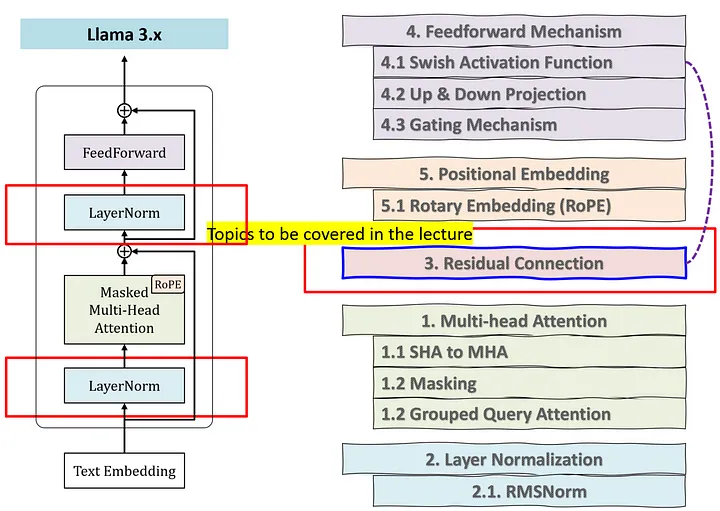

## Section 1: LLaMA Architecture Overview

### Decoder-Only Transformer (ASCII Diagram)

```
                        +------------------+
                        |   Output Logits  |
                        +--------+---------+
                                 |
                        +--------+---------+
                        |   Linear Head    |
                        +--------+---------+
                                 |
                        +--------+---------+
                        |    RMSNorm       |  <-- Final normalization
                        +--------+---------+
                                 |
                  +--------------+--------------+
                  |    x N Decoder Layers        |
                  |                              |
                  |  +------------------------+  |
                  |  |  RMSNorm (pre-norm)    |  |
                  |  +----------+-------------+  |
                  |             |                 |
                  |  +----------+-------------+  |
                  |  | Grouped-Query Attention |  |  <-- GQA (LLaMA 2+)
                  |  | with RoPE embeddings   |  |  <-- RoPE positional encoding
                  |  +----------+-------------+  |
                  |             |                 |
                  |       + Residual +            |
                  |             |                 |
                  |  +----------+-------------+  |
                  |  |  RMSNorm (pre-norm)    |  |
                  |  +----------+-------------+  |
                  |             |                 |
                  |  +----------+-------------+  |
                  |  |  SwiGLU FFN            |  |  <-- SwiGLU activation
                  |  |  (3 weight matrices)   |  |
                  |  +----------+-------------+  |
                  |             |                 |
                  |       + Residual +            |
                  |                              |
                  +--------------+---------------+
                                 |
                        +--------+---------+
                        |  Token Embedding |
                        |  (no pos embed)  |  <-- Position via RoPE only
                        +--------+---------+
                                 |
                        +--------+---------+
                        |   Input Tokens   |
                        +------------------+
```

### Key Innovations vs Original GPT

| Component | Original GPT | LLaMA |
|-----------|-------------|-------|
| **Normalization** | Post-LayerNorm | **Pre-RMSNorm** (more stable training) |
| **Activation** | GELU | **SwiGLU** (better performance) |
| **Positional Encoding** | Learned absolute | **RoPE** (relative, extrapolates better) |
| **Attention** | Multi-Head Attention | **Grouped-Query Attention** (LLaMA 2+) |
| **Bias terms** | Yes | **No** (removed from linear layers) |
| **Tied embeddings** | Yes (GPT-2) | **No** (separate input/output embeddings) |

> **Interview Key Point:** LLaMA is essentially a GPT-style decoder-only transformer with 4 surgical upgrades: RMSNorm, SwiGLU, RoPE, and GQA. These changes collectively improve training stability, model quality, and inference speed.

---

## Section 2: RMSNorm (Root Mean Square Layer Normalization)

### What is RMSNorm?

RMSNorm simplifies LayerNorm by removing the **mean-centering** step and only performing **scaling** based on the root mean square of the activations.

### Formula Comparison

**LayerNorm:**
$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

where $\mu = \frac{1}{n}\sum_{i=1}^{n} x_i$ and $\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2$

**RMSNorm:**
$$\text{RMSNorm}(x) = \gamma \cdot \frac{x}{\text{RMS}(x) + \epsilon}$$

where $\text{RMS}(x) = \sqrt{\frac{1}{n}\sum_{i=1}^{n} x_i^2}$

### Key Differences

| Aspect | LayerNorm | RMSNorm |
|--------|-----------|---------|
| Mean subtraction | Yes ($x - \mu$) | **No** |
| Learnable bias ($\beta$) | Yes | **No** |
| Learnable scale ($\gamma$) | Yes | Yes |
| Computational cost | Higher (mean + variance) | **Lower** (only RMS) |
| Speed improvement | Baseline | **~10-15% faster** |
| Re-centering invariance | Yes | No |
| Re-scaling invariance | Yes | Yes |

### Why Does Removing Mean-Centering Work?

The original LayerNorm paper hypothesized that both re-centering (mean subtraction) and re-scaling (variance division) are important. However, the RMSNorm paper (Zhang & Sennrich, 2019) showed empirically that:
- The **re-scaling invariance** is the key contributor to LayerNorm's success
- Re-centering provides negligible benefit in practice
- Removing it saves compute with no quality loss

### Where is RMSNorm Applied in LLaMA?

- **Pre-normalization**: RMSNorm is applied **before** each attention and FFN sub-layer (not after, like in original Transformer)
- **Final normalization**: RMSNorm before the output linear head

> **Interview Tip:** "RMSNorm removes the mean-centering step from LayerNorm, making it ~10-15% faster while maintaining the same model quality. LLaMA uses it in a pre-norm configuration, which stabilizes training for deep networks."

---

## Section 3: SwiGLU Activation Function

### What is SwiGLU?

SwiGLU is a **gated activation function** used in the Feed-Forward Network (FFN) of LLaMA. It was proposed by Noam Shazeer (2020) and combines the **Swish** activation with a **Gated Linear Unit (GLU)**.

### Formula

**Standard FFN (GPT):**
$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$
- Uses **2 weight matrices**: $W_1$ and $W_2$

**SwiGLU FFN (LLaMA):**
$$\text{SwiGLU}(x) = [\text{Swish}(xW_1) \odot (xV)] \cdot W_2$$
- Uses **3 weight matrices**: $W_1$, $V$, and $W_2$
- $\odot$ is element-wise multiplication (gating)
- No bias terms in LLaMA

where **Swish** (also called SiLU):
$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

### Step-by-Step Computation

```
Input x (dim: d_model)
    |
    +-----> xW1 (dim: d_ffn) ----> Swish activation ---+
    |                                                    |  element-wise multiply (gate)
    +-----> xV  (dim: d_ffn) --------------------------+
                                                        |
                                                   gated output (dim: d_ffn)
                                                        |
                                                   * W2 (dim: d_model)
                                                        |
                                                   Output (dim: d_model)
```

### Why 3 Matrices Instead of 2?

- The **gate** ($xV$) acts as a learned filter that decides which features to amplify/suppress
- To keep parameter count similar, LLaMA uses a smaller FFN hidden dim: $d_{ffn} = \frac{2}{3} \times 4d_{model}$ (rounded to multiple of 256)
- Standard FFN: $d_{ffn} = 4 \times d_{model}$

### Activation Function Comparison

| Activation | Formula | Used In | Notes |
|-----------|---------|---------|-------|
| ReLU | $\max(0, x)$ | Original Transformer | Dead neurons problem |
| GELU | $x \cdot \Phi(x)$ | GPT, BERT | Smooth approximation of ReLU |
| Swish/SiLU | $x \cdot \sigma(x)$ | EfficientNet | Smooth, non-monotonic |
| **SwiGLU** | $\text{Swish}(xW_1) \odot (xV)$ | **LLaMA, PaLM** | Gated, best empirical results |

> **Interview Tip:** "SwiGLU uses 3 weight matrices instead of 2, adding a gating mechanism. Despite the extra matrix, the hidden dimension is reduced to 2/3 of the standard 4x expansion, keeping total parameters similar while achieving better performance."

---

## Section 4: Rotary Positional Embedding (RoPE)

### The Problem with Positional Encodings

Transformers have no inherent notion of token order. We need to inject position information somehow:

### Intuition Behind RoPE

**Core idea:** Instead of *adding* position information to the embedding, RoPE *rotates* the embedding vector in 2D subspaces based on its position.

Think of it like a clock:
- Token at position 0 --> no rotation
- Token at position 1 --> small rotation
- Token at position 2 --> more rotation
- ...and so on

The **key mathematical property**: when you compute the dot product (attention score) between two rotated vectors, the result depends only on their **relative position** difference, not their absolute positions.

### Formula

For a query/key vector $x$ at position $m$, RoPE applies rotation in 2D subspaces:

$$f(x, m) = \begin{pmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \\ \vdots \end{pmatrix} \otimes \begin{pmatrix} \cos(m\theta_1) \\ \cos(m\theta_1) \\ \cos(m\theta_2) \\ \cos(m\theta_2) \\ \vdots \end{pmatrix} + \begin{pmatrix} -x_2 \\ x_1 \\ -x_4 \\ x_3 \\ \vdots \end{pmatrix} \otimes \begin{pmatrix} \sin(m\theta_1) \\ \sin(m\theta_1) \\ \sin(m\theta_2) \\ \sin(m\theta_2) \\ \vdots \end{pmatrix}$$

where $\theta_i = 10000^{-2i/d}$ (similar to sinusoidal PE frequencies)

### Key Properties of RoPE

1. **Relative position awareness**: $q_m^T k_n$ depends only on $(m - n)$, not on $m$ or $n$ individually
2. **No learnable parameters**: purely mathematical transformation (like sinusoidal PE)
3. **Applied to Q and K only**: not applied to Values (V) -- values don't need position info for attention weighting
4. **Long-range decay**: attention naturally decays for distant tokens (built-in recency bias)
5. **Extrapolation**: can extend to longer sequences than seen in training (with techniques like NTK-aware scaling)

### Positional Encoding Comparison

| Method | Type | Relative Position | Extrapolation | Used In |
|--------|------|-------------------|---------------|---------|
| **Learned Absolute** | Additive, learned | No | Poor | GPT-2, BERT |
| **Sinusoidal** | Additive, fixed | No (theoretically yes) | Moderate | Original Transformer |
| **ALiBi** | Attention bias | Yes (linear bias) | Good | BLOOM, MPT |
| **RoPE** | Multiplicative rotation | **Yes (via rotation)** | **Good (with scaling)** | **LLaMA, Mistral, Qwen** |

### How RoPE Enables Context Extension

LLaMA 3.1 extends context to 128K using RoPE scaling techniques:
- **Position Interpolation**: Scale positions by factor $s$: $f(x, m/s)$ -- compress positions to fit training range
- **NTK-aware Scaling**: Scale the base frequency ($10000 \to$ larger value) to preserve high-frequency components
- **YaRN**: Combines NTK scaling with attention scaling for best results

> **Interview Tip:** "RoPE encodes position by rotating query and key vectors. The dot product between two rotated vectors naturally captures relative position. It's applied only to Q and K, not to V. This is why LLaMA can extend context length through simple frequency scaling."

---

## Section 5: Grouped-Query Attention (GQA)

> For a deep dive into GQA, see **notebook 9.9.10 (KV Cache & GQA)**. This section provides a brief recap.

### The KV Cache Problem

During autoregressive inference, we cache Key and Value tensors to avoid recomputation. With **Multi-Head Attention (MHA)**, the KV cache grows linearly with:
- Sequence length
- Number of layers
- **Number of heads** (each head has its own K and V)

For LLaMA 70B with 64 heads, this becomes a memory bottleneck.

### MHA vs MQA vs GQA

```
Multi-Head Attention (MHA)          Multi-Query Attention (MQA)       Grouped-Query Attention (GQA)
========================          ===========================       =============================

Q:  [H1][H2][H3][H4][H5][H6]     Q:  [H1][H2][H3][H4][H5][H6]     Q:  [H1][H2][H3][H4][H5][H6]
     |    |    |    |    |    |          \   |   /   \   |   /              \  |  /      \  |  /
K:  [H1][H2][H3][H4][H5][H6]     K:       [H1]        [H1]          K:    [G1]          [G2]
V:  [H1][H2][H3][H4][H5][H6]     V:       [H1]        [H1]          V:    [G1]          [G2]

KV heads:  6 (= Q heads)          KV heads:  1 (shared)              KV heads:  2 (grouped)
KV cache:  LARGE                   KV cache:  SMALLEST                KV cache:  MODERATE
Quality:   BEST                    Quality:   DEGRADED                Quality:   NEAR-MHA
```

### GQA in LLaMA Models

| Model | Q Heads | KV Heads | Group Size | KV Cache Reduction |
|-------|---------|----------|------------|-------------------|
| LLaMA 1 (all sizes) | N | N (MHA) | 1 | None (full MHA) |
| LLaMA 2 7B | 32 | 32 (MHA) | 1 | None |
| LLaMA 2 13B | 40 | 40 (MHA) | 1 | None |
| LLaMA 2 70B | 64 | **8 (GQA)** | 8 | **8x reduction** |
| LLaMA 3 8B | 32 | **8 (GQA)** | 4 | **4x reduction** |
| LLaMA 3 70B | 64 | **8 (GQA)** | 8 | **8x reduction** |
| LLaMA 3.1 405B | 128 | **8 (GQA)** | 16 | **16x reduction** |

> **Interview Tip:** "GQA is the sweet spot between MHA (best quality, most memory) and MQA (least memory, quality loss). LLaMA 2 70B was the first LLaMA model to use GQA with 8 KV heads shared across 64 query heads, giving an 8x KV cache reduction with minimal quality loss."

---

## Section 6: LLaMA Version Comparison Table

| Feature | LLaMA 1 (Feb 2023) | LLaMA 2 (Jul 2023) | LLaMA 3 (Apr 2024) | LLaMA 3.1 (Jul 2024) |
|---------|-------------------|-------------------|-------------------|---------------------|
| **Parameters** | 7B, 13B, 33B, 65B | 7B, 13B, 70B | 8B, 70B | 8B, 70B, **405B** |
| **Context Length** | 2,048 | **4,096** | **8,192** | **128,000** |
| **Training Tokens** | 1.0T - 1.4T | **2.0T** | **15T+** | **15T+** |
| **Attention** | MHA (all sizes) | MHA (7B, 13B), **GQA (70B)** | **GQA (all sizes)** | **GQA (all sizes)** |
| **KV Heads** | = Q heads | 32/40/8 | 8 (all sizes) | 8 (all sizes) |
| **Tokenizer** | SentencePiece (32K vocab) | SentencePiece (32K vocab) | **tiktoken (128K vocab)** | **tiktoken (128K vocab)** |
| **Normalization** | RMSNorm | RMSNorm | RMSNorm | RMSNorm |
| **Activation** | SwiGLU | SwiGLU | SwiGLU | SwiGLU |
| **Positional Encoding** | RoPE | RoPE | RoPE | RoPE (with scaling) |
| **License** | Research only | **Commercial** (with limits) | **Community license** | **Community license** |
| **Chat/Instruct Model** | No (base only) | **Yes (LLaMA 2 Chat)** | **Yes (Instruct)** | **Yes (Instruct)** |
| **RLHF/Alignment** | None | **RLHF (PPO + Rejection Sampling)** | **RLHF + DPO** | **RLHF + DPO** |
| **Key Improvements** | First open LLM at scale | Longer context, RLHF, GQA | 4x larger vocab, 7x more data | **128K context, 405B model, tool use** |

### Notable Trends Across Versions

1. **Data scaling >> Parameter scaling**: LLaMA 3 8B outperforms LLaMA 2 70B on many benchmarks, trained on 15T tokens vs 2T
2. **GQA adoption**: Started as only 70B optimization, now used for all model sizes
3. **Vocabulary expansion**: 32K to 128K vocabulary (better multilingual + code support)
4. **Context length**: 2K to 128K (64x increase) via RoPE frequency scaling
5. **Alignment evolution**: No alignment -> RLHF -> RLHF + DPO

---

## Section 7: GPT vs LLaMA vs Mistral Comparison

| Feature | GPT-3/GPT-4 | LLaMA 3 (8B/70B) | Mistral 7B | Mixtral 8x7B |
|---------|-------------|-------------------|------------|--------------|
| **Developer** | OpenAI | Meta | Mistral AI | Mistral AI |
| **Open Weights** | No (closed API) | **Yes** | **Yes** | **Yes** |
| **Architecture** | Decoder-only | Decoder-only | Decoder-only | **Mixture-of-Experts** (MoE) |
| **Normalization** | LayerNorm (post) | **RMSNorm (pre)** | **RMSNorm (pre)** | **RMSNorm (pre)** |
| **Activation** | GELU | **SwiGLU** | **SwiGLU** | **SwiGLU** |
| **Positional Encoding** | Learned absolute (GPT-3) | **RoPE** | **RoPE** | **RoPE** |
| **Attention Type** | MHA (GPT-3), unknown (GPT-4) | **GQA** | **GQA** (sliding window) | **GQA** (sliding window) |
| **Sliding Window Attn** | No | No | **Yes** (W=4096) | **Yes** (W=4096) |
| **Context Length** | 8K-128K (GPT-4) | 8K (base) | 8K (v0.1), 32K (v0.2) | 32K |
| **Vocabulary Size** | ~100K (GPT-4) | **128K** | 32K | 32K |
| **MoE** | Rumored (GPT-4) | No | No | **Yes** (8 experts, top-2) |
| **Active Parameters** | All | All | All | **~13B** (of 46.7B total) |
| **Training Data** | Proprietary | 15T tokens (public) | Undisclosed | Undisclosed |
| **Bias Terms** | Yes (GPT-3) | No | No | No |

### Mistral-Specific Innovations

1. **Sliding Window Attention (SWA)**: Each layer attends to only the last W=4096 tokens, but information propagates through layers (effective receptive field = W x num_layers)
2. **Mixture of Experts (Mixtral)**: 8 expert FFN blocks per layer, router selects top-2 per token. Only ~13B parameters active per forward pass despite 46.7B total parameters
3. **Rolling Buffer KV Cache**: Fixed-size KV cache that overwrites old entries, capping memory usage

### Key Architectural Takeaway

```
Modern Open LLM Recipe (2024+):
    Base:        Decoder-only Transformer
    Norm:        RMSNorm (pre-norm)        <-- from LLaMA
    Activation:  SwiGLU                     <-- from PaLM/LLaMA
    Position:    RoPE                       <-- from RoFormer/LLaMA
    Attention:   GQA                        <-- from LLaMA 2
    Optional:    Sliding Window (Mistral), MoE (Mixtral/DeepSeek)
```

> **Interview Tip:** "LLaMA essentially defined the modern open LLM architecture. Mistral, Qwen, Yi, and most recent open models all use the same core recipe (RMSNorm + SwiGLU + RoPE + GQA). Mistral's main additions are sliding window attention and Mixture of Experts."

---

## Section 8: Top 10 LLaMA Architecture Interview Q&A

---

### Q1: What are the key architectural differences between LLaMA and the original GPT?

**A:** LLaMA makes 4 main changes to the GPT decoder-only architecture:
1. **RMSNorm** instead of LayerNorm (faster, applied pre-norm instead of post-norm)
2. **SwiGLU** instead of GELU activation (better quality, uses 3 weight matrices in FFN)
3. **RoPE** instead of learned absolute positional embeddings (relative position, better extrapolation)
4. **GQA** instead of standard MHA (reduced KV cache, faster inference -- introduced in LLaMA 2)
5. Additionally: no bias terms in linear layers, untied input/output embeddings

---

### Q2: What is RMSNorm and why does LLaMA use it instead of LayerNorm?

**A:** RMSNorm normalizes by the root mean square of activations, removing the mean-centering step from LayerNorm. This makes it ~10-15% faster with no quality loss. LLaMA uses it in a **pre-norm** configuration (normalize before each sub-layer), which provides more stable gradients during training compared to post-norm.

---

### Q3: Explain SwiGLU. Why does it use 3 matrices instead of 2?

**A:** SwiGLU computes: $\text{Swish}(xW_1) \odot (xV) \cdot W_2$. The third matrix $V$ creates a **gate** -- a learned signal that controls which features pass through. This gating mechanism improves expressiveness. To compensate for the extra parameters, the hidden dimension is reduced to $\frac{2}{3} \times 4d$ instead of the standard $4d$, keeping total parameter count similar.

---

### Q4: How does RoPE encode position information? Why is it applied only to Q and K?

**A:** RoPE rotates query and key vectors in 2D subspaces by angles proportional to their position. The critical property is that the dot product $q_m^T k_n$ depends only on the **relative distance** $(m-n)$, not absolute positions. It's applied only to Q and K because attention weights (computed from Q-K dot products) are what need position sensitivity. Values (V) represent content that gets aggregated by attention weights and don't need position encoding.

---

### Q5: What is Grouped-Query Attention and when was it introduced in LLaMA?

**A:** GQA groups multiple query heads to share a single KV head. It was introduced in **LLaMA 2 70B** (8 KV heads for 64 query heads = 8x KV cache reduction). By LLaMA 3, all model sizes use GQA. It's a middle ground between MHA (each query has its own KV = best quality) and MQA (all queries share 1 KV head = most memory efficient but quality degrades).

---

### Q6: How did LLaMA 3.1 achieve 128K context length from LLaMA 1's 2K?

**A:** Through **RoPE frequency scaling**. The key techniques are:
- **Position Interpolation**: Scale positions to fit within the original training range
- **NTK-aware scaling**: Adjust the base frequency of RoPE to preserve high-frequency position information
- Progressive training: Train at shorter context first, then gradually extend
- The RoPE formulation naturally supports this because it's a continuous function of position.

---

### Q7: Why did LLaMA 3 increase vocabulary from 32K to 128K tokens?

**A:** A larger vocabulary means:
- **Better tokenization efficiency**: Common words/subwords get single tokens (fewer tokens per sentence = faster inference)
- **Better multilingual support**: More room for non-English scripts
- **Better code support**: Programming tokens are better represented
- Trade-off: larger embedding table (more parameters), but improved throughput more than compensates

---

### Q8: What is the significance of "pre-norm" vs "post-norm"?

**A:**
- **Post-norm** (original Transformer): output = LayerNorm(x + sublayer(x)) -- normalize after residual
- **Pre-norm** (LLaMA): output = x + sublayer(RMSNorm(x)) -- normalize before sub-layer

Pre-norm provides **better gradient flow** because the residual connection passes through without normalization. This makes training more stable for very deep networks (>30 layers) and often eliminates the need for learning rate warmup.

---

### Q9: Compare LLaMA and Mistral architectures. What does Mistral add?

**A:** Mistral uses the same base recipe as LLaMA (RMSNorm + SwiGLU + RoPE + GQA) but adds:
1. **Sliding Window Attention**: Each layer attends to only the last 4096 tokens instead of all tokens. Information still propagates to distant tokens through stacked layers.
2. **Mixtral adds MoE**: 8 expert FFN blocks per layer with a router selecting top-2 per token. This gives 46.7B total params but only ~13B active per token, achieving near-70B quality at 13B inference cost.

---

### Q10: If you had to build a new LLM from scratch today, which components from LLaMA would you keep and what might you change?

**A:** **Keep from LLaMA:**
- RMSNorm (pre-norm) -- proven stable, fast
- SwiGLU activation -- consistently outperforms alternatives
- RoPE -- best balance of relative position encoding and extrapolation
- GQA -- essential for inference efficiency

**Potential changes:**
- **MoE** (like Mixtral/DeepSeek): more compute-efficient for same quality
- **Sliding window + global attention hybrid**: reduce memory for very long contexts
- **Multi-token prediction** (LLaMA 3 explored this): predict multiple future tokens for faster inference
- **Longer training on more data**: Chinchilla-optimal or beyond (LLaMA 3 showed data scaling is crucial)

---

## Section 9: References

1. **LLaMA 1**: Touvron et al., "LLaMA: Open and Efficient Foundation Language Models" (2023) - [arXiv:2302.13971](https://arxiv.org/abs/2302.13971)
2. **LLaMA 2**: Touvron et al., "LLaMA 2: Open Foundation and Fine-Tuned Chat Models" (2023) - [arXiv:2307.09288](https://arxiv.org/abs/2307.09288)
3. **LLaMA 3**: Meta AI, "The LLaMA 3 Herd of Models" (2024) - [arXiv:2407.21783](https://arxiv.org/abs/2407.21783)
4. **RMSNorm**: Zhang & Sennrich, "Root Mean Square Layer Normalization" (2019) - [arXiv:1910.07467](https://arxiv.org/abs/1910.07467)
5. **SwiGLU**: Shazeer, "GLU Variants Improve Transformer" (2020) - [arXiv:2002.05202](https://arxiv.org/abs/2002.05202)
6. **RoPE**: Su et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding" (2021) - [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
7. **GQA**: Ainslie et al., "GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints" (2023) - [arXiv:2305.13245](https://arxiv.org/abs/2305.13245)
8. **Mistral 7B**: Jiang et al., "Mistral 7B" (2023) - [arXiv:2310.06825](https://arxiv.org/abs/2310.06825)
9. **Mixtral**: Jiang et al., "Mixtral of Experts" (2024) - [arXiv:2401.04088](https://arxiv.org/abs/2401.04088)

---

*Cross-references: See notebook **9.9.10** for detailed KV Cache & GQA coverage, **9.0 transformer** for base Transformer architecture.*